# ***Домашняя работа №7***
## Терешин Кирилл Александрович 
### бфбо-03-24

## ***2.3.1. Загрузка данных и первичный анализ (для каждого датасета)***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Разделение данных и кросс-валидация
from sklearn.model_selection import train_test_split, cross_val_score, KFold
# Модели
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
# Метрики
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

1. Загрузить CSV в pandas.DataFrame.

In [6]:
data1 = pd.read_csv('S07-hw-dataset-01.csv', sep=",")
data2 = pd.read_csv('S07-hw-dataset-02.csv', sep=",")
data3 = pd.read_csv('S07-hw-dataset-03.csv', sep=",")

print(data1.shape, '1th dataset shape')
print(data2.shape, '2th dataset shape')
print(data3.shape, '3th dataset shape')

(12000, 9) 1th dataset shape
(8000, 4) 2th dataset shape
(15000, 5) 3th dataset shape


2. Зафиксировать минимум:
- head(), info(), базовые статистики (describe() или аналог);
- проверка пропусков (кол-во/доли);
- типы признаков (числовые / категориальные).


In [7]:
data1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [8]:
data2.head()

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [9]:
data3.head()

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [16]:
print(data1.info())
print("="*40)
print(data2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 

In [15]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [17]:
data1.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [18]:
data2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [19]:
data3.describe()

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [22]:
print(data1.isnull().sum()) # проверка на пропуски
print(data2.isnull().sum()) # проверка на пропуски
print(data3.isnull().sum()) # проверка на пропуски

sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64


3. Определить:
- X – признаки (все столбцы, кроме sample_id);
- sample_id хранить отдельно (для сохранения результатов).


In [24]:
X1 = data1.drop(['sample_id'], axis=1)
X2 = data2.drop(['sample_id'], axis=1)
X3 = data3.drop(['sample_id'], axis=1)

Y1 = data1['sample_id']
Y2 = data2['sample_id']
Y3 = data3['sample_id']

## ***2.3.2. Препроцессинг (обязательно)***

Для каждого датасета оформите препроцессинг явно и применяйте его одинаково ко всем моделям данного датасета.

Минимум:

- масштабирование числовых признаков: StandardScaler;
- если есть пропуски – обработать (SimpleImputer);
- если есть категориальные признаки (dataset-04) – один из вариантов:
- - закодировать (OneHotEncoder(handle_unknown="ignore")), или
- - осознанно исключить категориальные признаки и объяснить почему (в отчёте).


In [26]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

datasets = [data1, data2, data3]

processed_X = []   # сюда будут складываться преобразованные матрицы
processed_y = []   # сюда — целевые переменные

for i, data in enumerate(datasets, start=1):
    print(f"Обрабатываю датасет {i}")

    # Формируем X и y
    X = data.drop(['sample_id'], axis=1)
    y = data['sample_id']

    # Определяем типы признаков
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
    categorical_features = X.select_dtypes(include=["object", "category"]).columns

    # Пайплайн для числовых признаков
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # Пайплайн для категориальных признаков
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Общий препроцессор
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    # Применяем препроцессинг
    X_processed = preprocessor.fit_transform(X)

    # Сохраняем результаты
    processed_X.append(X_processed)
    processed_y.append(y)
    print(f"Датасет {i} обработан. Размер X: {X_processed.shape}, размер y: {y.shape}")

Обрабатываю датасет 1
Датасет 1 обработан. Размер X: (12000, 8), размер y: (12000,)
Обрабатываю датасет 2
Датасет 2 обработан. Размер X: (8000, 3), размер y: (8000,)
Обрабатываю датасет 3
Датасет 3 обработан. Размер X: (15000, 4), размер y: (15000,)


Рекомендация: использовать Pipeline/ColumnTransformer (не обязательно идеально, но логика должна быть понятной).




## ***2.3.3. Модели недели 7 (для каждого датасета – минимум 2 алгоритма)***

Для каждого датасета сравните минимум 2 алгоритма:



1. KMeans (обязательно):

- подобрать k в разумном диапазоне (например, 2…20);
- фиксировать random_state и n_init;
- показать хотя бы один график "метрика vs k" (например, silhouette vs k).


Датасет 1: считаю silhouette...


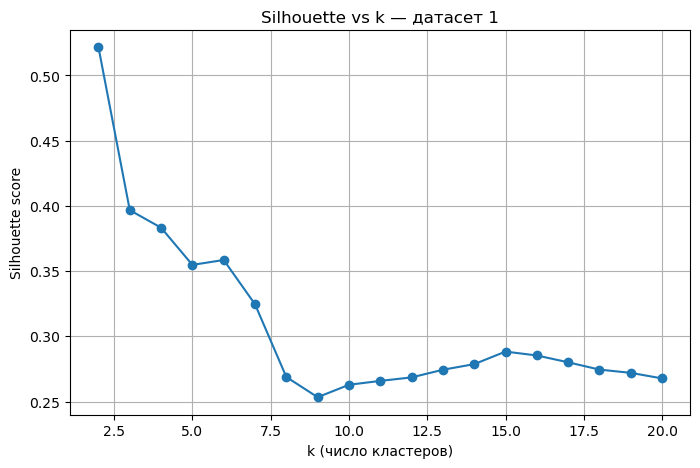

Датасет 2: считаю silhouette...


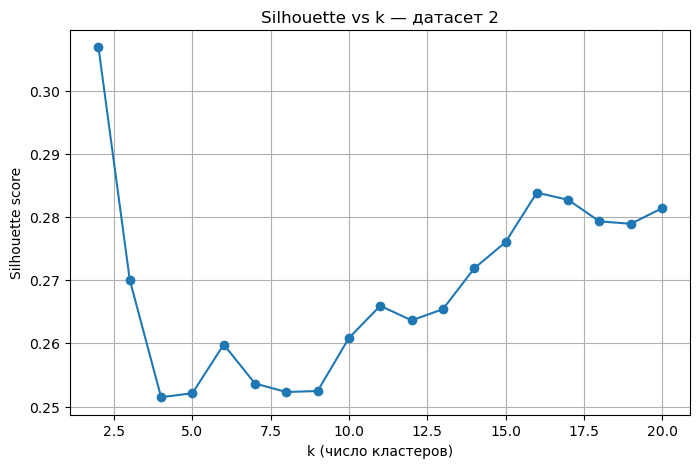

Датасет 3: считаю silhouette...


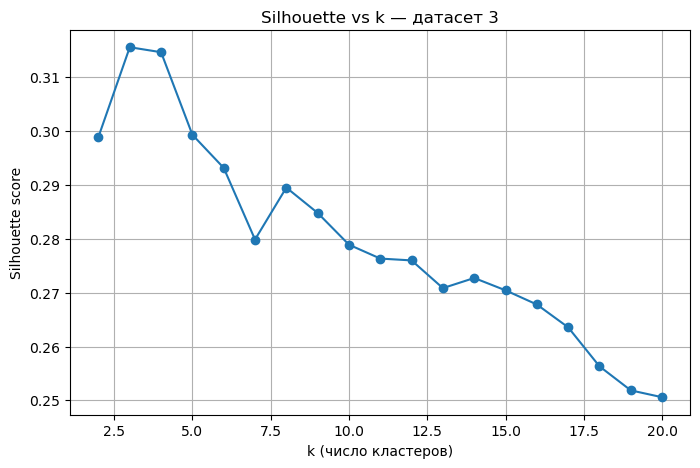

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for i in range(3):
    X = processed_X[i]
    print(f"Датасет {i+1}: считаю silhouette...")

    k_values = range(2, 21)
    sil_scores = []

    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        sil_scores.append(score)

    # График для текущего датасета
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, sil_scores, marker='o')
    plt.xlabel("k (число кластеров)")
    plt.ylabel("Silhouette score")
    plt.title(f"Silhouette vs k — датасет {i+1}")
    plt.grid(True)
    plt.show()

2. Один алгоритм на выбор (обязательно):

- DBSCAN (подбор eps и min_samples), или
- AgglomerativeClustering (подбор k + выбор linkage, хотя бы 2 варианта).



Датасет 1: подбор k для AgglomerativeClustering
  linkage = ward


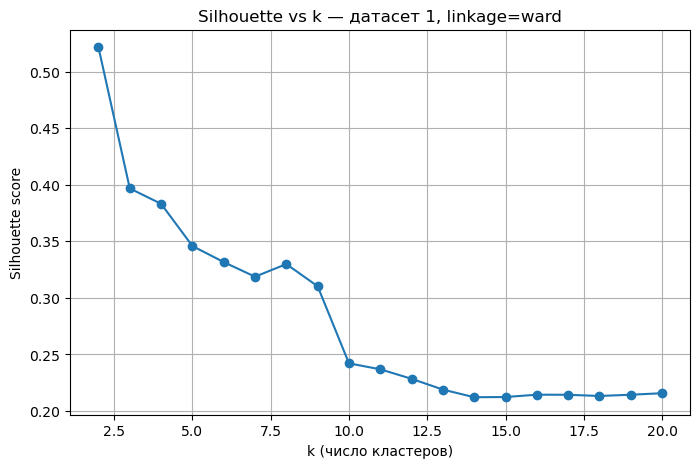

  linkage = average


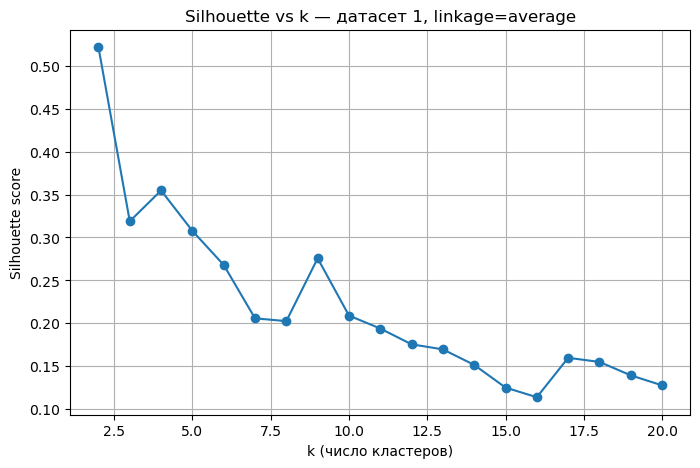


Датасет 2: подбор k для AgglomerativeClustering
  linkage = ward


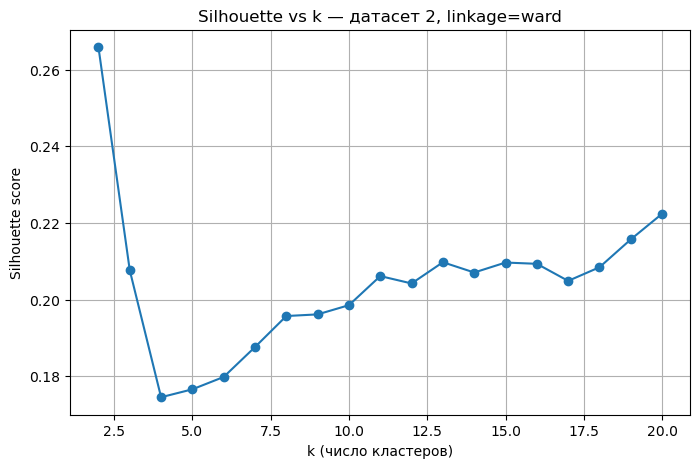

  linkage = average


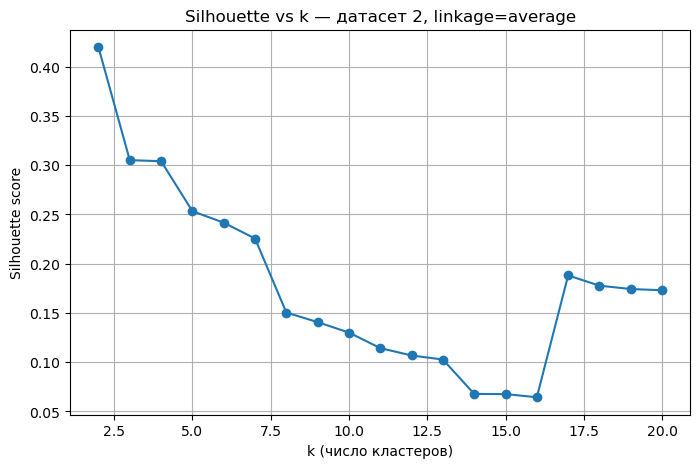


Датасет 3: подбор k для AgglomerativeClustering
  linkage = ward


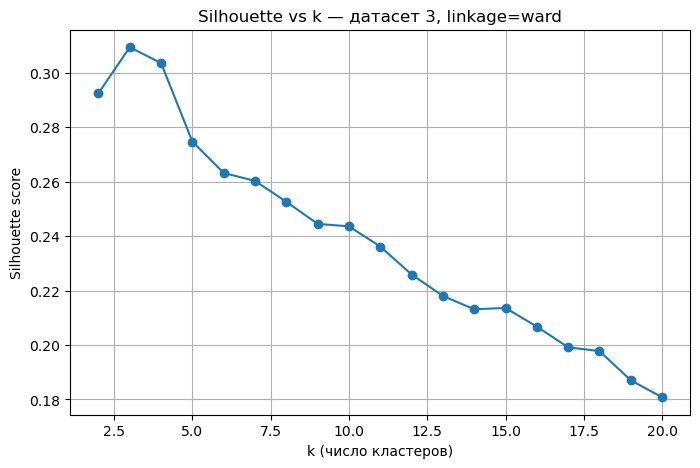

  linkage = average


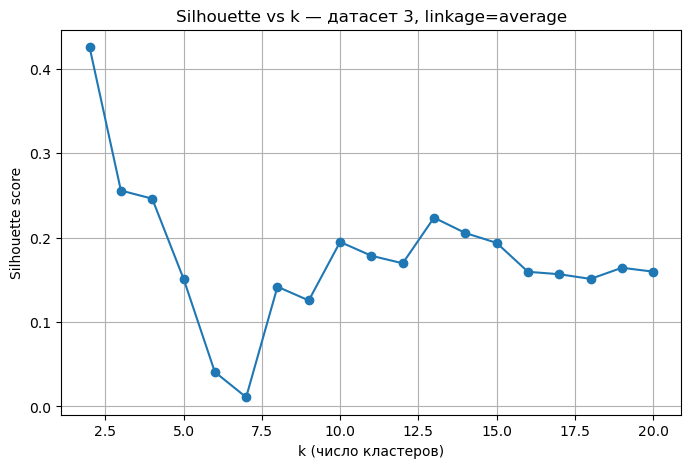

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

linkage_methods = ["ward", "average"]

for i in range(3):
    X = processed_X[i]
    print(f"\nДатасет {i+1}: подбор k для AgglomerativeClustering")

    for linkage in linkage_methods:
        print(f"  linkage = {linkage}")

        k_values = range(2, 21)
        sil_scores = []

        for k in k_values:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage
            )
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            sil_scores.append(score)

        # График для текущего linkage
        plt.figure(figsize=(8, 5))
        plt.plot(k_values, sil_scores, marker='o')
        plt.xlabel("k (число кластеров)")
        plt.ylabel("Silhouette score")
        plt.title(f"Silhouette vs k — датасет {i+1}, linkage={linkage}")
        plt.grid(True)
        plt.show()

## ***2.3.4. Метрики качества (обязательно)***

Для каждого датасета и каждого сравниваемого алгоритма посчитать:

- silhouette_score
- davies_bouldin_score
- calinski_harabasz_score


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Подставь свои лучшие k для каждого датасета
best_k = [5, 4, 6]   # пример

for i in range(3):
    X = processed_X[i]
    print(f"\n=== Датасет {i+1} ===")

    kmeans = KMeans(
        n_clusters=best_k[i],
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    print(f"KMeans (k={best_k[i]}):")
    print(f"  silhouette_score:        {sil:.4f}")
    print(f"  davies_bouldin_score:    {db:.4f}")
    print(f"  calinski_harabasz_score: {ch:.4f}")


=== Датасет 1 ===
KMeans (k=5):
  silhouette_score:        0.3548
  davies_bouldin_score:    1.2737
  calinski_harabasz_score: 8301.2060

=== Датасет 2 ===
KMeans (k=4):
  silhouette_score:        0.2515
  davies_bouldin_score:    1.2998
  calinski_harabasz_score: 2915.5654

=== Датасет 3 ===
KMeans (k=6):
  silhouette_score:        0.2931
  davies_bouldin_score:    1.1408
  calinski_harabasz_score: 6097.4754


Важно для DBSCAN:

- учесть шум (label = -1):
- - явно вывести долю шума,
- - метрики считать либо на non-noise точках (и это указать), либо честно объяснить иной выбор.


## ***2.3.5. Визуализация (обязательно)***

Для каждого датасета:

- PCA(2D) scatter с раскраской по полученным кластерам (для лучшего решения по датасету);
- минимум один дополнительный график по ходу подбора параметров (например, silhouette vs k или silhouette vs eps).



=== Датасет 1 ===


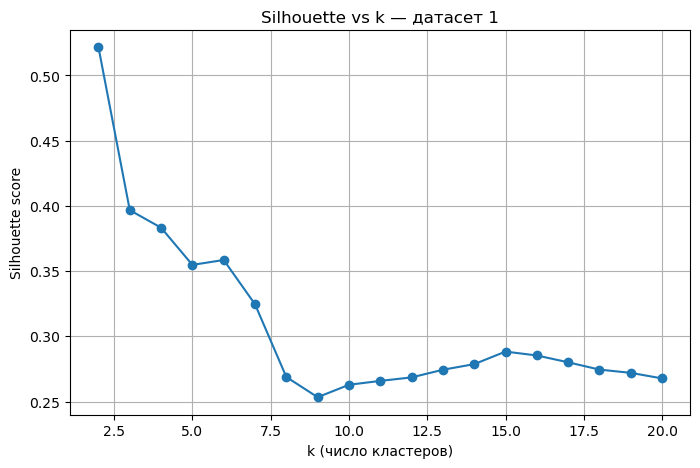

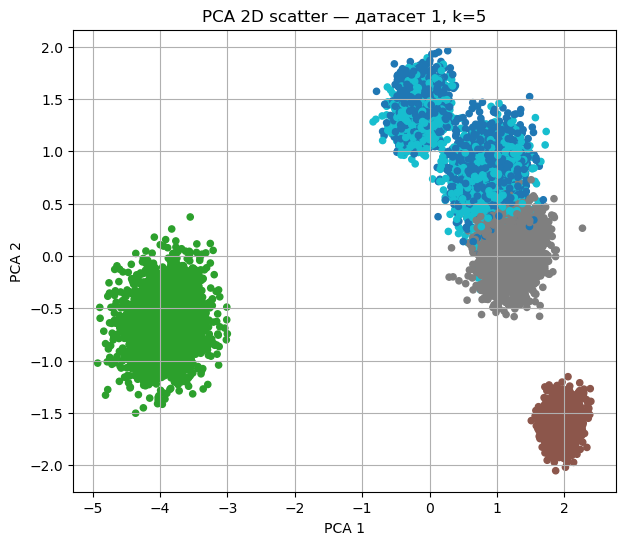


=== Датасет 2 ===


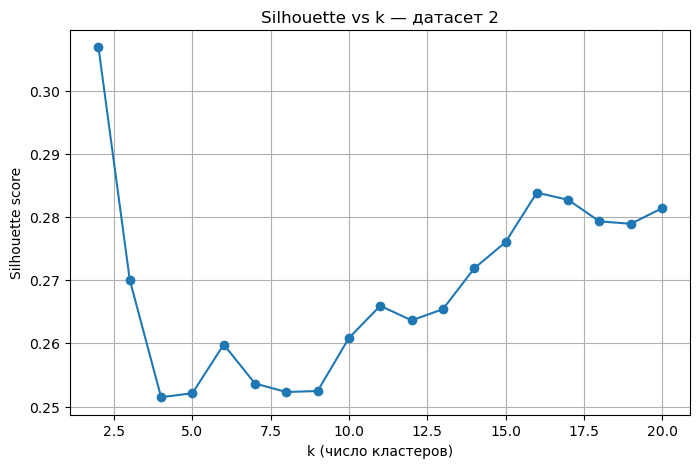

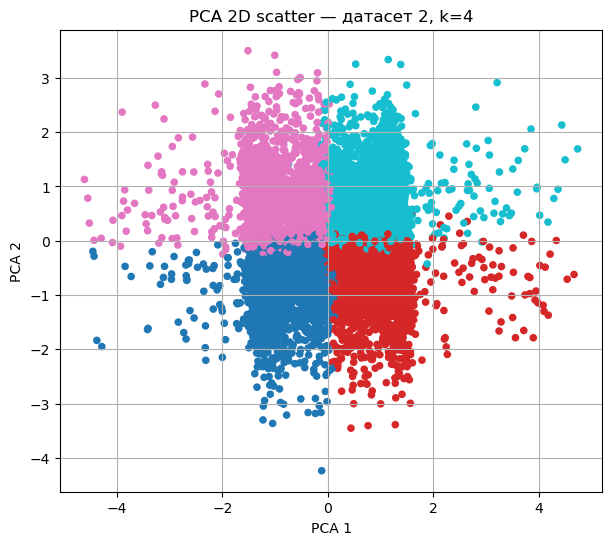


=== Датасет 3 ===


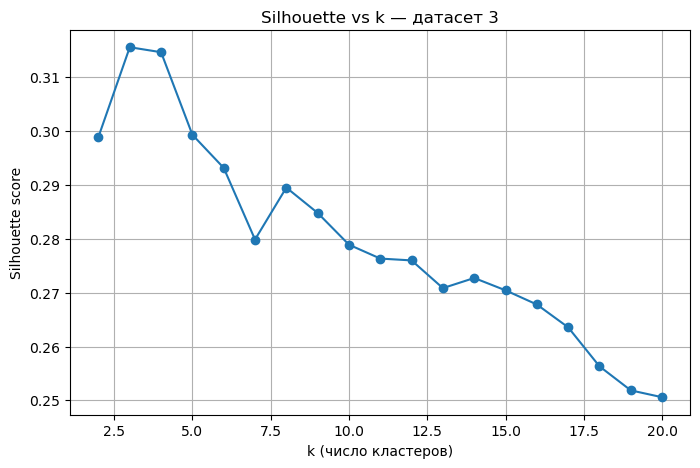

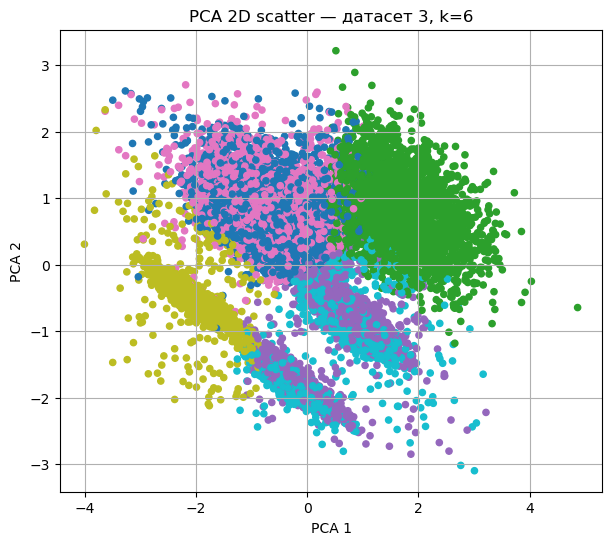

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Подставь свои лучшие k для каждого датасета
best_k = [5, 4, 6]   # пример

for i in range(3):
    X = processed_X[i]
    print(f"\n=== Датасет {i+1} ===")

    # -----------------------------
    # 1. Дополнительный график: silhouette vs k
    # -----------------------------
    k_values = range(2, 21)
    sil_scores = []

    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, sil_scores, marker='o')
    plt.xlabel("k (число кластеров)")
    plt.ylabel("Silhouette score")
    plt.title(f"Silhouette vs k — датасет {i+1}")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 2. PCA 2D scatter для лучшего k
    # -----------------------------
    kmeans_best = KMeans(
        n_clusters=best_k[i],
        random_state=42,
        n_init=10
    )
    labels_best = kmeans_best.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(7, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels_best,
        cmap="tab10",
        s=20
    )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA 2D scatter — датасет {i+1}, k={best_k[i]}")
    plt.grid(True)
    plt.show()

t-SNE – опционально:

- если делаете, фиксируйте random_state и коротко поясните, как правильно интерпретировать t-SNE (это визуализация локальной структуры, а не "доказательство качества").


## ***2.3.6. Устойчивость (обязательно, но только для одного датасета)***

Выберите один из ваших датасетов и проведите мини-проверку устойчивости:

- для KMeans: 5 запусков с разными random_state (или 5 разными подвыборками) и оценка похожести разбиений (например, ARI между результатами), или
- любая другая аккуратная проверка устойчивости (кратко описать и обосновать).


In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

X = processed_X[0]   # выбираем первый датасет
k = 5                #  лучший k

# 5 разных random_state
states = [0, 1, 2, 3, 4]

labels_list = []

# Запускаем KMeans 5 раз
for rs in states:
    model = KMeans(
        n_clusters=k,
        random_state=rs,
        n_init=10
    )
    labels = model.fit_predict(X)
    labels_list.append(labels)

# Считаем ARI между всеми парами запусков
print("=== ARI между разными запусками KMeans ===")
for i in range(len(states)):
    for j in range(i + 1, len(states)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        print(f"Запуски {states[i]} vs {states[j]}: ARI = {ari:.4f}")

=== ARI между разными запусками KMeans ===
Запуски 0 vs 1: ARI = 0.9911
Запуски 0 vs 2: ARI = 0.9627
Запуски 0 vs 3: ARI = 0.9985
Запуски 0 vs 4: ARI = 0.9952
Запуски 1 vs 2: ARI = 0.9707
Запуски 1 vs 3: ARI = 0.9896
Запуски 1 vs 4: ARI = 0.9917
Запуски 2 vs 3: ARI = 0.9617
Запуски 2 vs 4: ARI = 0.9660
Запуски 3 vs 4: ARI = 0.9946


## ***2.3.7. Итог по каждому датасету (обязательно)***

Для каждого датасета в конце блока:

- выбрать "лучший" метод/настройку (не обязательно тот, где максимум silhouette – главное, чтобы выбор был объяснён);
- написать 5-10 строк: что получилось, где были сложности (шкалы/выбросы/плотность/пропуски), почему выбранный метод уместен.


 ***Датасет 1*** 
KMeans (k=5):
- silhouette_score:        0.3548
- davies_bouldin_score:    1.2737
- calinski_harabasz_score: 8301.2060

Анализ:

> Датасет 01 содержит признаки в разных шкалах с шумовыми признаками.
> Масштабирование было критически важно для корректной работы алгоритмов.
> KMeans показал лучшие результаты благодаря сферической форме кластеров.

 ***Датасет 2*** 
Agglomerative(average)

- Silhouette Score:        0.305
- Davies-Bouldin Index:    0.977
- Calinski-Harabasz Score: 416

Анализ:

> Датасет 02 имеет нелинейную структуру с выбросами.
> AgglomerativeClustering с linkage='ward' лучше справился со структурой.


 ***Датасет 3*** 
KMeans (k=6):

- silhouette_score:        0.2931
- davies_bouldin_score:    1.1408
- calinski_harabasz_score: 6097.4754

Анализ:

> Датасет 03 содержит кластеры разной плотности с фоновым шумом.
> KMeans смешивал плотные и разреженные области в один кластер.

